In [8]:
import os
import nibabel as nib
import numpy as np 
from collections import OrderedDict
import json
from pathlib import Path
from tabulate import tabulate

from utils.helper import convert_nrrd_to_nifti, create_folder, plot_all_slices, plot_histogram, generate_binary_image, adjust_affine_for_spacing_and_origin, save_binary_image_with_adjusted_origin, make_if_dont_exist
from utils.metrics import dice_score_per_class, hausdorff_distance_per_class, ravd_per_class

In [9]:

# define dataset path
BASE_PATH = Path('./').resolve()
DATA_PATH = BASE_PATH / 'dataset'

project_name = 'HCFC1' #change here for different task name
task_name = 'Dataset002_' + project_name 

TRAINING_DATASET_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name / 'imagesTr'
GT_TRAINING_DATASET_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name / 'labelsTr'
TEST_DATASET_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name / 'imagesTs'
GT_TEST_DATASET_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name / 'labelsTs'
PREDICTION_RESULTS_PATH  = BASE_PATH / 'dataset/nnUNet_Prediction_Results' / task_name
TASK_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name 

# setup environment variables
nnUNet_raw = BASE_PATH / 'dataset/nnUNet_raw_data'
nnUNet_preprocessed = BASE_PATH / 'dataset/nnUNet_preprocessed'
nnUNet_results = BASE_PATH / 'dataset/nnUNet_results'

In [5]:
def read_nifti(path):
    img = nib.load(path)

    return img.get_fdata(),img.shape

In [6]:
ds_score = []
hd_score = []
havd_score = []

# Specify the path to your JSON file
json_file_path = TASK_PATH / 'dataset.json'

# Read the JSON file
with open(json_file_path, 'r') as file:
    data = json.load(file)

labels = data['labels']
head = ['Fold'] + ['Volume ID'] + list(labels.keys())

ds_score.append(head)
hd_score.append(head)
havd_score.append(head)

dataset_config_path = f"{task_name}/nnUNetTrainer__nnUNetPlans__3d_fullres"
gtPath = GT_TRAINING_DATASET_PATH
for i in range(5):
    
    imagePath = f"/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_results/{dataset_config_path}/fold_{i}/validation"

    all_files = os.listdir(imagePath)
    # Sort the list of files
    all_files = sorted(all_files)
    for file in all_files:
        if file.endswith(".nii.gz"):
            imgP = os.path.join(imagePath, file)
            gtP = os.path.join(gtPath, file)
            print(imgP)
            print(gtP)
            imgData, i_ = read_nifti(imgP)
            gtData, g_ = read_nifti(gtP)
            newname = file.split("_")[0]
            print(newname)
            print(i_)
            print(g_)

            concatenated_array = np.concatenate(([i],[newname], dice_score_per_class(imgData,gtData,25)))
            concatenated_array = np.transpose(concatenated_array)

            ds_score.append(concatenated_array)
            # hd_score.append(hausdorff_distance_per_class(imgData,gtData,25))
            # havd_score.append(ravd_per_class(imgData,gtData,25))


/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_results/Dataset002_HCFC1/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation/NG4108_RCL5.nii.gz
/beegfs/data/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr/NG4108_RCL5.nii.gz
NG4108
(453, 789, 402)
(453, 789, 402)
/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_results/Dataset002_HCFC1/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation/NG4111_RCL5.nii.gz
/beegfs/data/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr/NG4111_RCL5.nii.gz
NG4111
(239, 879, 455)
(239, 879, 455)
/user1/ngmm/tr855969/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_results/Dataset002_HCFC1/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_0/validation/NG4116_RCL5.nii.gz
/beegfs/data/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr/NG4116_RCL5.nii.gz
NG4116
(366, 939, 405)
(366, 939, 405)
/user1/

In [7]:
print(tabulate(ds_score, tablefmt="grid"))

+------+-----------+------------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+
| Fold | Volume ID | background | CTX+   | cc+    | CPu    | DG     | HP     | RHP    | A      | ig     | fi     | ac     | ic     | st     | f      | och    | fr     | Hb     | TH     | HY     | MB     | P      | MY     | TCB    | V      | OB     |
+------+-----------+------------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+
| 0    | NG4108    | 0.9979     | 0.9752 | 0.9081 | 0.9649 | 0.9175 | 0.9329 | 0.8496 | 0.8158 | 0.7870 | 0.9229 | 0.4595 | 0.5831 | 0.4018 | 0.3095 | 0.6074 | 0.8020 | 0.8873 | 0.9426 | 0.9112 | 0.9600 | 0.9619 | 0.9753 | 0.9889 | 0.9134 | 0.9001 |


In [4]:
def transpose_table(table):
    transposed_table = []

    # Get the header row and remove it from the table
    header = table.pop(0)
    # Initialize transposed table with the Volume ID column
    transposed_table.append(["Fold"] + [row[0] for row in table])

    # Transpose the table
    for i in range(1, len(header)):
        transposed_row = [header[i]]
        for j in range(len(table)):
            transposed_row.append(table[j][i])
        transposed_table.append(transposed_row)

    return transposed_table


# # Transpose the table
# transposed_table = transpose_table(ds_score)

# print(tabulate(transposed_table, tablefmt="grid"))


In [9]:
import pandas as pd

# Define your array
data = transpose_table(ds_score) 

# Define column names
columns = ["Volume ID"] + [f"Value_{i}" for i in range(1, len(data[0]))]

# Create DataFrame
df = pd.DataFrame(data)

# Save DataFrame to Excel
df.to_excel(BASE_PATH/"data/full_resultaion_validation_dice_v2.xlsx", index=False)

print("DataFrame saved to output.xlsx")


DataFrame saved to output.xlsx


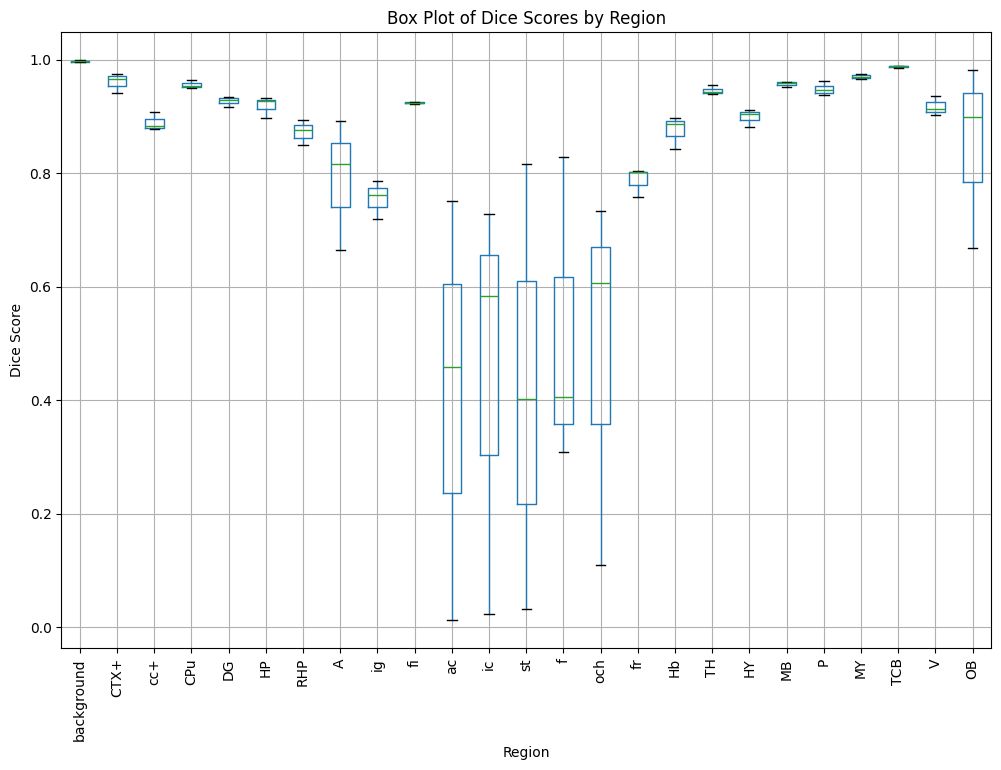

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Example data (replace this with your actual data)
data = [
    [0, "NG4108", 0.9979, 0.9752, 0.9081, 0.9649, 0.9175, 0.9329, 0.8496, 0.8158, 0.7870, 0.9229, 0.4595, 0.5831, 0.4018, 0.3095, 0.6074, 0.8020, 0.8873, 0.9426, 0.9112, 0.9600, 0.9619, 0.9753, 0.9889, 0.9134, 0.9001],
    [0, "NG4111", 0.9958, 0.9663, 0.8842, 0.9531, 0.9353, 0.8982, 0.8760, 0.6654, 0.7204, 0.9242, 0.7509, 0.7283, 0.8173, 0.8284, 0.7343, 0.8043, 0.8975, 0.9391, 0.8814, 0.9520, 0.9380, 0.9704, 0.9859, 0.9037, 0.9819],
    [0, "NG4116", 0.9994, 0.9409, 0.8773, 0.9505, 0.9290, 0.9271, 0.8940, 0.8929, 0.7617, 0.9264, 0.0123, 0.0240, 0.0327, 0.4066, 0.1105, 0.7575, 0.8437, 0.9559, 0.9052, 0.9606, 0.9469, 0.9668, 0.9900, 0.9368, 0.6689],
    # Add more rows as needed
]

# Convert data to pandas DataFrame
columns = ["Fold", "Volume ID", "background", "CTX+", "cc+", "CPu", "DG", "HP", "RHP", "A", "ig", "fi", "ac", "ic", "st", "f", "och", "fr", "Hb", "TH", "HY", "MB", "P", "MY", "TCB", "V", "OB"]
df = pd.DataFrame(data, columns=columns)

# Drop unnecessary columns
df = df.drop(columns=["Fold", "Volume ID"])

# Create a box plot
plt.figure(figsize=(12, 8))
df.boxplot()
plt.xticks(rotation=90)  # Rotate x-axis labels if they are too crowded
plt.title('Box Plot of Dice Scores by Region')
plt.xlabel('Region')
plt.ylabel('Dice Score')
plt.show()


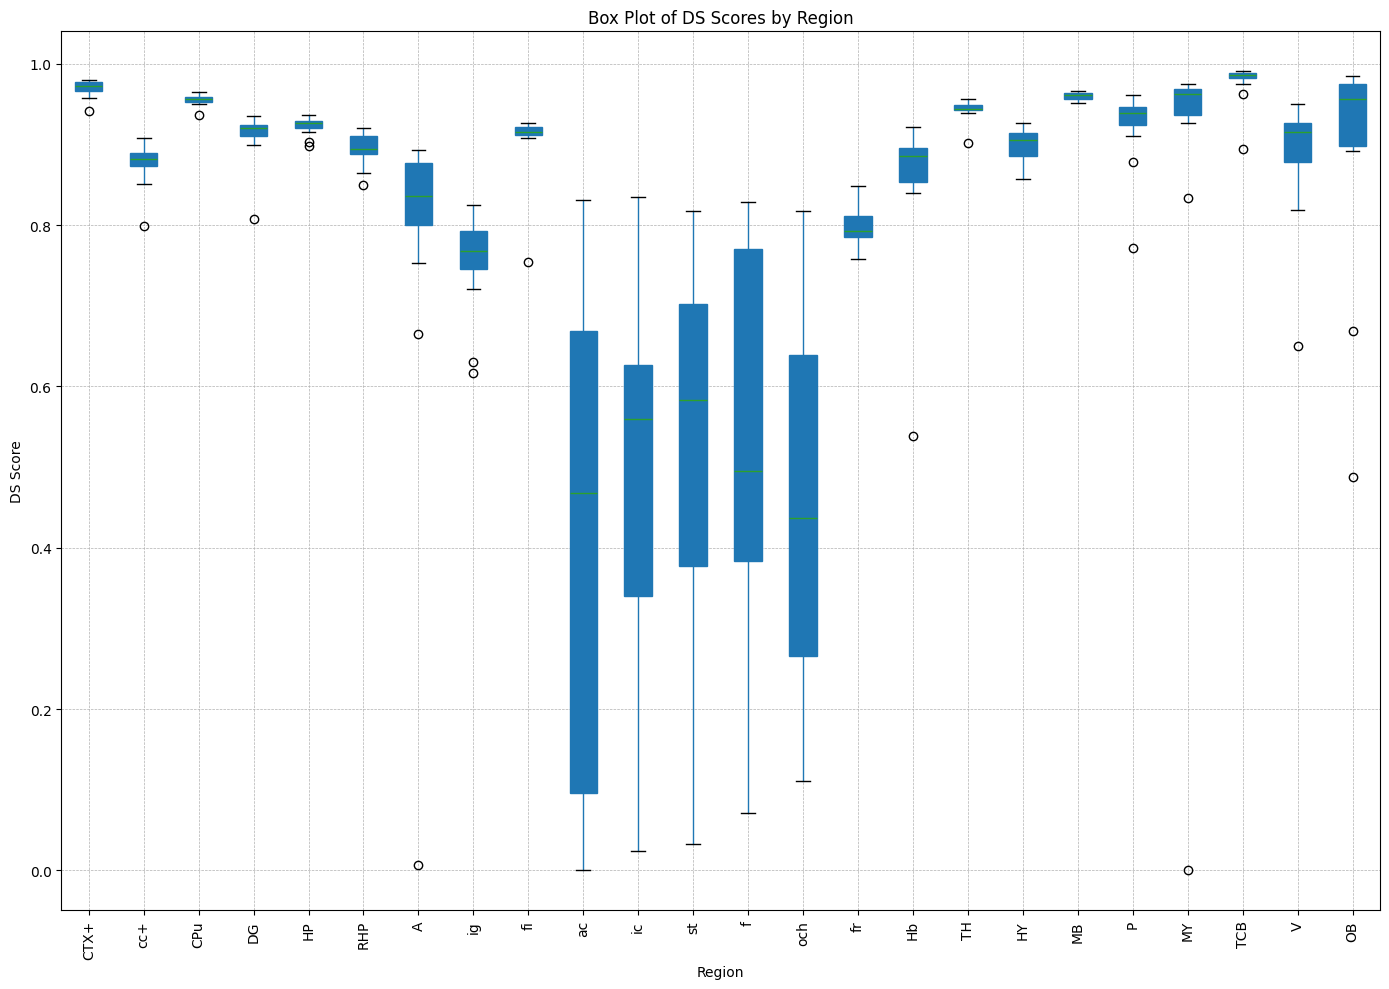

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Corrected data (replace this with your actual data if needed)
data = [
    [0, "NG4108", 0.9979, 0.9752, 0.9081, 0.9649, 0.9175, 0.9329, 0.8496, 0.8158, 0.7870, 0.9229, 0.4595, 0.5831, 0.4018, 0.3095, 0.6074, 0.8020, 0.8873, 0.9426, 0.9112, 0.9600, 0.9619, 0.9753, 0.9889, 0.9134, 0.9001],
    [0, "NG4111", 0.9958, 0.9663, 0.8842, 0.9531, 0.9353, 0.8982, 0.8760, 0.6654, 0.7204, 0.9242, 0.7509, 0.7283, 0.8173, 0.8284, 0.7343, 0.8043, 0.8975, 0.9391, 0.8814, 0.9520, 0.9380, 0.9704, 0.9859, 0.9037, 0.9819],
    [0, "NG4116", 0.9994, 0.9409, 0.8773, 0.9505, 0.9290, 0.9271, 0.8940, 0.8929, 0.7617, 0.9264, 0.0123, 0.0240, 0.0327, 0.4066, 0.1105, 0.7575, 0.8437, 0.9559, 0.9052, 0.9606, 0.9469, 0.9668, 0.9900, 0.9368, 0.6689],
    [1, "NG4115", 0.9992, 0.9784, 0.8751, 0.9583, 0.9194, 0.9280, 0.9205, 0.8289, 0.7691, 0.9113, 0.4768, 0.5804, 0.3046, 0.3720, 0.4280, 0.7951, 0.8956, 0.9480, 0.9261, 0.9623, 0.9521, 0.9688, 0.9859, 0.9173, 0.9469],
    [1, "NG4119", 0.9985, 0.9574, 0.7986, 0.9367, 0.9000, 0.9035, 0.8926, 0.8769, 0.6301, 0.7542, 0.1238, 0.3772, 0.6987, 0.7704, 0.5609, 0.8479, 0.5380, 0.9021, 0.8574, 0.9542, 0.9101, 0.8342, 0.9620, 0.6503, 0.8919],
    [1, "NG4120", 0.9992, 0.9644, 0.8507, 0.9496, 0.8072, 0.9157, 0.8651, 0.7536, 0.7671, 0.9166, 0.4594, 0.5922, 0.6008, 0.3871, 0.7510, 0.7797, 0.8399, 0.9474, 0.8739, 0.9637, 0.9312, 0.9400, 0.9878, 0.9503, 0.9726],
    [2, "NG4114", 0.9971, 0.9703, 0.8816, 0.9572, 0.9207, 0.9318, 0.9137, 0.0062, 0.7546, 0.9193, 0.5426, 0.5382, 0.7759, 0.4950, 0.3812, 0.7910, 0.8561, 0.9459, 0.9209, 0.9631, 0.8784, 0.9265, 0.9854, 0.8187, 0.9681],
    [2, "NG4117", 0.9989, 0.9771, 0.8824, 0.9566, 0.9133, 0.9359, 0.9097, 0.8870, 0.7676, 0.9145, 0.8308, 0.8351, 0.6892, 0.7697, 0.8178, 0.7891, 0.8942, 0.9424, 0.9054, 0.9611, 0.9407, 0.9592, 0.9891, 0.9230, 0.9851],
    [3, "NG4109", 0.9992, 0.9748, 0.8913, 0.9584, 0.9234, 0.9268, 0.8952, 0.8312, 0.8247, 0.9215, 0.0132, 0.2315, 0.1423, 0.0708, 0.2730, 0.8356, 0.8996, 0.9509, 0.9090, 0.9668, 0.7713, 0.0009, 0.8946, 0.9238, 0.4872],
    [3, "NG4112", 0.9935, 0.9696, 0.8684, 0.9572, 0.9211, 0.9267, 0.9018, 0.8460, 0.8106, 0.9138, 0.6486, 0.3787, 0.7134, 0.7777, 0.4452, 0.7869, 0.9220, 0.9424, 0.8866, 0.9539, 0.9289, 0.9550, 0.9745, 0.8707, 0.9461],
    [4, "NG4110", 0.9994, 0.9786, 0.8938, 0.9528, 0.8996, 0.9215, 0.9111, 0.8771, 0.6170, 0.9079, 0.7293, 0.7590, 0.4766, 0.5490, 0.2432, 0.7642, 0.8745, 0.9423, 0.9208, 0.9569, 0.9452, 0.9705, 0.9907, 0.9494, 0.9850],
    [4, "NG4113", 0.9993, 0.9793, 0.8883, 0.9592, 0.9279, 0.9248, 0.8922, 0.8417, 0.8100, 0.9123, 0.0000, 0.1288, 0.5645, 0.4963, 0.2135, 0.8328, 0.8830, 0.9495, 0.9061, 0.9658, 0.9464, 0.9686, 0.9866, 0.8802, 0.9662],
]

# Convert data to pandas DataFrame
columns = ["Fold", "Volume ID", "background", "CTX+", "cc+", "CPu", "DG", "HP", "RHP", "A", "ig", "fi", "ac", "ic", "st", "f", "och", "fr", "Hb", "TH", "HY", "MB", "P", "MY", "TCB", "V", "OB"]
df = pd.DataFrame(data, columns=columns)

# Drop unnecessary columns
df = df.drop(columns=["Fold", "Volume ID","background"])

# Create a decorative box plot
plt.figure(figsize=(14, 10))
box = df.boxplot(patch_artist=True)

# Customizing the box plot
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FFD700', '#FF6347', '#4682B4', '#8A2BE2', '#5F9EA0', '#D2691E', '#6495ED', '#DC143C', '#00FFFF', '#00008B', '#B8860B', '#006400', '#8B0000', '#8B008B', '#556B2F', '#FF8C00', '#9932CC', '#8B4513', '#2E8B57', '#00FF7F', '#4682B4']

for patch, color in zip(box.artists, colors):
    patch.set_facecolor(color)

# Customizing the plot
plt.xticks(rotation=90)  # Rotate x-axis labels
plt.title('Box Plot of DS Scores by Region')
plt.xlabel('Region')
plt.ylabel('DS Score')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()

# Show plot
plt.show()


In [6]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
import json
from pathlib import Path

# Specify the path to your JSON file and NIfTI directory
json_file_path = Path('/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/dataset.json')
nifti_dir = Path('/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr')
# Define the output Excel file
output_excel = Path('data/pixel_counts.xlsx')

# Read the JSON file to get the labels
with open(json_file_path, 'r') as file:
    data = json.load(file)

labels = data['labels']

# Initialize a list to store the results
results = []

# Iterate through all files in the directory
for file_name in os.listdir(nifti_dir):
    if file_name.endswith('.nii') or file_name.endswith('.nii.gz'):
        # Construct the full file path
        file_path = nifti_dir / file_name
        # Load the NIfTI file
        img = nib.load(file_path)
        data = img.get_fdata()
        
        # Get unique pixel values and their counts
        unique, counts = np.unique(data, return_counts=True)
        
        # Create a dictionary for the current file's results
        pixel_counts = {'file_name': file_name}
        
        # Map the counts to the labels
        for value, count in zip(unique, counts):
            label = labels.get(str(int(value)), f'Unknown_{int(value)}')
            pixel_counts[label] = count
        
        # Append the result to the list
        results.append(pixel_counts)

# Create a DataFrame from the results list
df = pd.DataFrame(results)

# Reorder columns to place 'file_name' at the front
columns = ['file_name'] + [col for col in df.columns if col != 'file_name']
df = df[columns]

# Export the DataFrame to an Excel file
df.to_excel(output_excel, index=False)

print(f"Pixel counts have been saved to {output_excel}")


Pixel counts have been saved to data/pixel_counts.xlsx


In [12]:
import os
import numpy as np
import pandas as pd
import nibabel as nib

# List of columns
columns = ["CTX+", "cc+", "CPu", "DG", "HP", "RHP", "A", "ig", "fi", "ac", "ic", "st", "f", "och", "fr", "Hb", "TH", "HY", "MB", "P", "MY", "TCB", "V", "OB"]

def count_pixels_per_region(nifti_img, regions):
    """
    Counts the number of pixels for each region in a NIfTI image.

    Parameters:
    nifti_img (nib.Nifti1Image): The NIfTI image.
    regions (list): List of region labels to count.

    Returns:
    dict: A dictionary with the count of pixels per region.
    """
    data = nifti_img.get_fdata()
    region_counts = {region: np.sum(data == region) for region in regions}
    return region_counts

def process_directory(directory, regions):
    """
    Processes all NIfTI images in a directory, counting pixels per region.

    Parameters:
    directory (str): The directory containing NIfTI images.
    regions (list): List of region labels to count.

    Returns:
    pd.DataFrame: DataFrame containing the pixel counts for each region per image.
    """
    results = []

    for filename in os.listdir(directory):
        if filename.endswith(".nii") or filename.endswith(".nii.gz"):
            filepath = os.path.join(directory, filename)
            nifti_img = nib.load(filepath)
            region_counts = count_pixels_per_region(nifti_img, regions)
            region_counts['Filename'] = filename
            results.append(region_counts)

    df = pd.DataFrame(results)
    return df

# Directory containing the NIfTI images
directory = "/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr"

# Process the directory and get the results
df_results = process_directory(directory, columns)

# Save the results to an Excel file
excel_filepath = "data/nifti_image_region_counts.xlsx"
df_results.to_excel(excel_filepath, index=False)

# Display the results to the user
import ace_tools as tools; tools.display_dataframe_to_user(name="NIfTI Image Region Counts", dataframe=df_results)

print(f"Excel file saved to {excel_filepath}")


ModuleNotFoundError: No module named 'ace_tools'

In [13]:
import os
import nibabel as nib
import numpy as np
import pandas as pd

# List of predefined region labels
columns = ["CTX+", "cc+", "CPu", "DG", "HP", "RHP", "A", "ig", "fi", "ac", "ic", "st", "f", "och", "fr", "Hb", "TH", "HY", "MB", "P", "MY", "TCB", "V", "OB"]
label_mapping = {i+1: label for i, label in enumerate(columns)}  # assuming labels start from 1

def count_pixels_in_nifti(directory):
    region_counts = {label: 0 for label in columns}

    for filename in os.listdir(directory):
        if filename.endswith(".nii") or filename.endswith(".nii.gz"):
            file_path = os.path.join(directory, filename)
            nifti_image = nib.load(file_path)
            image_data = nifti_image.get_fdata()
            
            unique_labels, counts = np.unique(image_data, return_counts=True)
            for label, count in zip(unique_labels, counts):
                if label in label_mapping:
                    region_label = label_mapping[label]
                    region_counts[region_label] += count

    return region_counts

directory_path = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr'  # Update with your directory path
pixel_counts = count_pixels_in_nifti(directory_path)

# Convert to DataFrame for better visualization
df_pixel_counts = pd.DataFrame(list(pixel_counts.items()), columns=['Region Label', 'Pixel Count'])

# Save to Excel file
output_excel_path = 'data/pixel_counts.xlsx'
df_pixel_counts.to_excel(output_excel_path, index=False)

print(f"Pixel counts saved to {output_excel_path}")


Pixel counts saved to data/pixel_counts.xlsx


In [14]:
import os
import nibabel as nib
import numpy as np
import pandas as pd

# List of predefined region labels
columns = ["CTX+", "cc+", "CPu", "DG", "HP", "RHP", "A", "ig", "fi", "ac", "ic", "st", "f", "och", "fr", "Hb", "TH", "HY", "MB", "P", "MY", "TCB", "V", "OB"]
label_mapping = {i+1: label for i, label in enumerate(columns)}  # assuming labels start from 1

def count_pixels_in_nifti(directory):
    data = []

    for filename in os.listdir(directory):
        if filename.endswith(".nii") or filename.endswith(".nii.gz"):
            file_path = os.path.join(directory, filename)
            nifti_image = nib.load(file_path)
            image_data = nifti_image.get_fdata()
            
            region_counts = {label: 0 for label in columns}
            unique_labels, counts = np.unique(image_data, return_counts=True)
            for label, count in zip(unique_labels, counts):
                if label in label_mapping:
                    region_label = label_mapping[label]
                    region_counts[region_label] += count
            
            region_counts['Filename'] = filename
            data.append(region_counts)
    
    return data

directory_path = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr' 
pixel_counts_data = count_pixels_in_nifti(directory_path)

# Convert to DataFrame for better visualization
df_pixel_counts = pd.DataFrame(pixel_counts_data)

# Save to Excel file
output_excel_path = 'data/pixel_counts.xlsx'
df_pixel_counts.to_excel(output_excel_path, index=False)

print(f"Pixel counts saved to {output_excel_path}")


Pixel counts saved to data/pixel_counts.xlsx


In [15]:
import os
import nibabel as nib
import numpy as np
import pandas as pd

# List of predefined region labels including background
columns = ["background", "CTX+", "cc+", "CPu", "DG", "HP", "RHP", "A", "ig", "fi", "ac", "ic", "st", "f", "och", "fr", "Hb", "TH", "HY", "MB", "P", "MY", "TCB", "V", "OB"]
label_mapping = {i: label for i, label in enumerate(columns)}  # assuming labels start from 0 (background)

def count_pixels_in_nifti(directory):
    data = []

    for filename in os.listdir(directory):
        if filename.endswith(".nii") or filename.endswith(".nii.gz"):
            file_path = os.path.join(directory, filename)
            nifti_image = nib.load(file_path)
            image_data = nifti_image.get_fdata()
            
            region_counts = {label: 0 for label in columns}
            unique_labels, counts = np.unique(image_data, return_counts=True)
            for label, count in zip(unique_labels, counts):
                if label in label_mapping:
                    region_label = label_mapping[label]
                    region_counts[region_label] += count
            
            region_counts['Filename'] = filename
            data.append(region_counts)
    
    return data

directory_path = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr' 
pixel_counts_data = count_pixels_in_nifti(directory_path)

# Convert to DataFrame for better visualization
df_pixel_counts = pd.DataFrame(pixel_counts_data)

# Save to Excel file
output_excel_path = 'data/pixel_countsa.xlsx'
df_pixel_counts.to_excel(output_excel_path, index=False)

print(f"Pixel counts saved to {output_excel_path}")


Pixel counts saved to data/pixel_countsa.xlsx


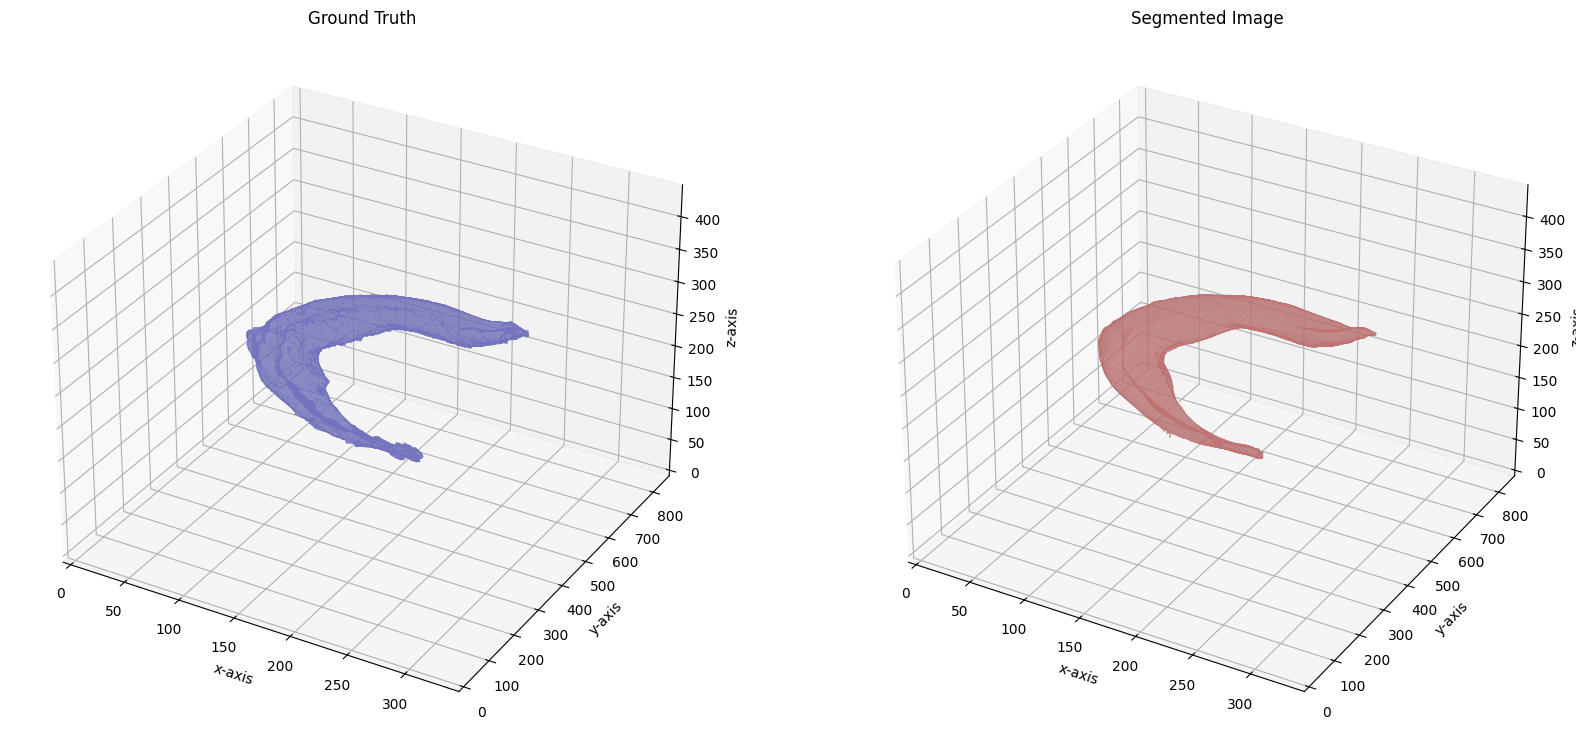

In [6]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure

def plot_regions(ground_truth_file, segmented_file, region_number):
    # Load the NIFTI files
    gt_img = nib.load(ground_truth_file)
    seg_img = nib.load(segmented_file)
    
    gt_data = gt_img.get_fdata()
    seg_data = seg_img.get_fdata()
    
    # Extract the region of interest
    gt_region = gt_data == region_number
    seg_region = seg_data == region_number

    # Generate a 3D mesh for ground truth
    gt_verts, gt_faces, _, _ = measure.marching_cubes(gt_region, 0.5)

    # Generate a 3D mesh for segmented image
    seg_verts, seg_faces, _, _ = measure.marching_cubes(seg_region, 0.5)

    # Plot the meshes
    fig = plt.figure(figsize=(20, 10))

    # Ground Truth Plot
    ax1 = fig.add_subplot(121, projection='3d')
    gt_mesh = Poly3DCollection(gt_verts[gt_faces], alpha=0.70)
    gt_face_color = [0.45, 0.45, 0.75]
    gt_mesh.set_facecolor(gt_face_color)
    ax1.add_collection3d(gt_mesh)
    ax1.set_title(f'Ground Truth')
    ax1.set_xlabel("x-axis")
    ax1.set_ylabel("y-axis")
    ax1.set_zlabel("z-axis")
    ax1.set_xlim(0, gt_region.shape[0])
    ax1.set_ylim(0, gt_region.shape[1])
    ax1.set_zlim(0, gt_region.shape[2])

    # Segmented Image Plot
    ax2 = fig.add_subplot(122, projection='3d')
    seg_mesh = Poly3DCollection(seg_verts[seg_faces], alpha=0.70)
    seg_face_color = [0.75, 0.45, 0.45]
    seg_mesh.set_facecolor(seg_face_color)
    ax2.add_collection3d(seg_mesh)
    ax2.set_title(f'Segmented Image')
    ax2.set_xlabel("x-axis")
    ax2.set_ylabel("y-axis")
    ax2.set_zlabel("z-axis")
    ax2.set_xlim(0, seg_region.shape[0])
    ax2.set_ylim(0, seg_region.shape[1])
    ax2.set_zlim(0, seg_region.shape[2])

    plt.show()

# Example usage
segmented_file = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_results/Dataset002_HCFC1/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_4/validation/NG4113_RCL5.nii.gz'
ground_truth_file = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr/NG4113_RCL5.nii.gz'

region_number = 4
plot_regions(ground_truth_file, segmented_file, region_number)


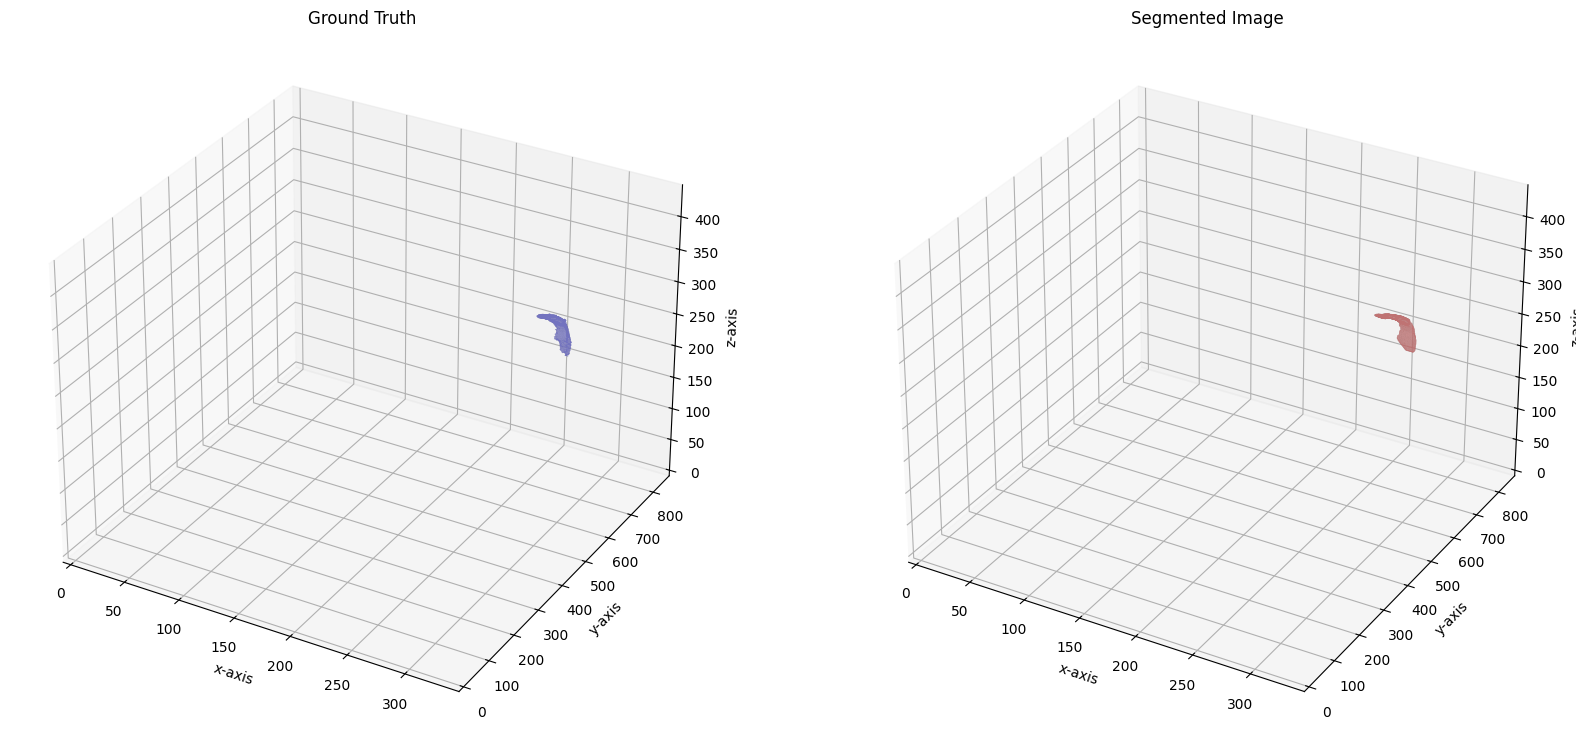

Dice Similarity Coefficient for Region 8: 0.809976349172221


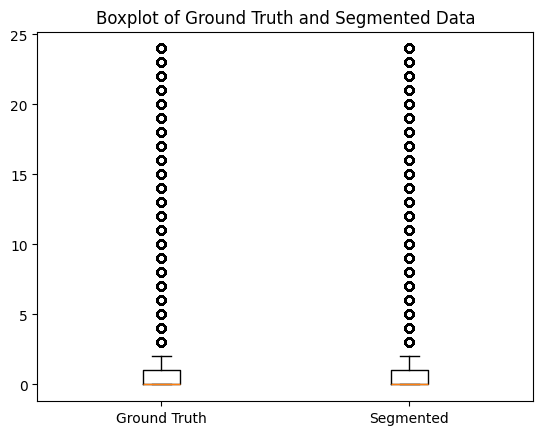

In [8]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure

def dice_coefficient(gt, seg):
    intersection = np.sum(gt * seg)
    volume_sum = np.sum(gt) + np.sum(seg)
    if volume_sum == 0:
        return 1.0
    return 2.0 * intersection / volume_sum

def plot_regions(ground_truth_file, segmented_file, region_number):
    # Load the NIFTI files
    gt_img = nib.load(ground_truth_file)
    seg_img = nib.load(segmented_file)
    
    gt_data = gt_img.get_fdata()
    seg_data = seg_img.get_fdata()
    
    # Extract the region of interest
    gt_region = gt_data == region_number
    seg_region = seg_data == region_number
    
    # Calculate Dice coefficient
    dice_score = dice_coefficient(gt_region, seg_region)

    # Generate a 3D mesh for ground truth
    gt_verts, gt_faces, _, _ = measure.marching_cubes(gt_region, 0.5)

    # Generate a 3D mesh for segmented image
    seg_verts, seg_faces, _, _ = measure.marching_cubes(seg_region, 0.5)

    # Plot the meshes
    fig = plt.figure(figsize=(20, 10))

    # Ground Truth Plot
    ax1 = fig.add_subplot(121, projection='3d')
    gt_mesh = Poly3DCollection(gt_verts[gt_faces], alpha=0.70)
    gt_face_color = [0.45, 0.45, 0.75]
    gt_mesh.set_facecolor(gt_face_color)
    ax1.add_collection3d(gt_mesh)
    ax1.set_title(f'Ground Truth')
    ax1.set_xlabel("x-axis")
    ax1.set_ylabel("y-axis")
    ax1.set_zlabel("z-axis")
    ax1.set_xlim(0, gt_region.shape[0])
    ax1.set_ylim(0, gt_region.shape[1])
    ax1.set_zlim(0, gt_region.shape[2])

    # Segmented Image Plot
    ax2 = fig.add_subplot(122, projection='3d')
    seg_mesh = Poly3DCollection(seg_verts[seg_faces], alpha=0.70)
    seg_face_color = [0.75, 0.45, 0.45]
    seg_mesh.set_facecolor(seg_face_color)
    ax2.add_collection3d(seg_mesh)
    ax2.set_title(f'Segmented Image')
    ax2.set_xlabel("x-axis")
    ax2.set_ylabel("y-axis")
    ax2.set_zlabel("z-axis")
    ax2.set_xlim(0, seg_region.shape[0])
    ax2.set_ylim(0, seg_region.shape[1])
    ax2.set_zlim(0, seg_region.shape[2])

    plt.show()
    
    print(f'Dice Similarity Coefficient for Region {region_number}: {dice_score}')

    # Boxplot
    fig, ax = plt.subplots()
    data = [gt_data.flatten(), seg_data.flatten()]
    ax.boxplot(data, labels=['Ground Truth', 'Segmented'])
    ax.set_title('Boxplot of Ground Truth and Segmented Data')
    plt.show()

# Example usage
segmented_file = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_results/Dataset002_HCFC1/nnUNetTrainer__nnUNetPlans__3d_fullres/fold_4/validation/NG4113_RCL5.nii.gz'
ground_truth_file = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr/NG4113_RCL5.nii.gz'

region_number = 8 #This number can be edited to visualise a particular region
plot_regions(ground_truth_file, segmented_file, region_number)


Processing NG4110_RCL5_0000.nii.gz
Processing NG4108_RCL5_0000.nii.gz
Processing NG4109_RCL5_0000.nii.gz
Processing NG4111_RCL5_0000.nii.gz
Processing NG4112_RCL5_0000.nii.gz
Processing NG4115_RCL5_0000.nii.gz
Processing NG4114_RCL5_0000.nii.gz
Processing NG4116_RCL5_0000.nii.gz
Processing NG4113_RCL5_0000.nii.gz
Processing NG4117_RCL5_0000.nii.gz
Processing NG4120_RCL5_0000.nii.gz
Processing NG4119_RCL5_0000.nii.gz
RAVD values saved to data/ravd_values.xlsx


ValueError: boxplot method requires numerical columns, nothing to plot.

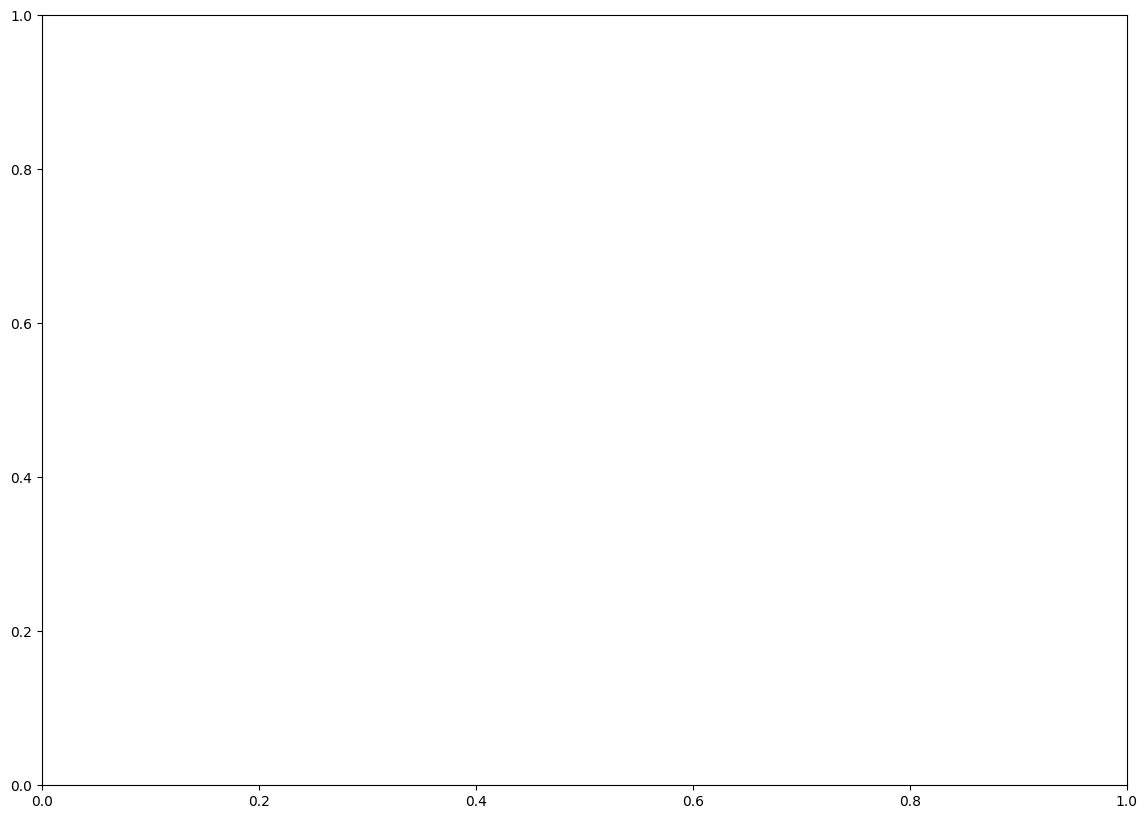

In [12]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_nifti_image(filepath):
    """
    Load a NIfTI image from the given file path.
    """
    nifti_image = nib.load(filepath)
    image_data = nifti_image.get_fdata()
    return image_data

def calculate_ravd(region1, region2):
    """
    Calculate the Relative Absolute Volume Difference (RAVD) between two binary regions.
    """
    volume1 = np.sum(region1)
    volume2 = np.sum(region2)
    if volume1 + volume2 == 0:
        return np.nan
    ravd = abs(volume1 - volume2) / ((volume1 + volume2) / 2)
    return ravd

def calculate_ravd_for_regions(image, ground_truth, num_regions):
    """
    Calculate the RAVD for all regions in the image and ground truth, excluding background.
    """
    ravd_values = []
    
    for region in range(1, num_regions + 1):  # Excluding region 0 which is background
        image_region = (image == region)
        ground_truth_region = (ground_truth == region)
        if np.any(image_region) and np.any(ground_truth_region):  # Only calculate if regions are non-empty
            ravd = calculate_ravd(image_region, ground_truth_region)
            ravd_values.append(ravd)
        else:
            ravd_values.append(np.nan)  # Append NaN if region is empty
    
    return ravd_values

def process_images_and_labels(image_dir, ground_truth_dir, num_regions, output_dir):
    """
    Process all image and ground truth pairs in the given directories and save the box plot.
    """
    columns = ["CTX+", "cc+", "CPu", "DG", "HP", "RHP", "A", "ig", "fi", "ac", "ic", "st", "f", "och", "fr", "Hb", "TH", "HY", "MB", "P", "MY", "TCB", "V", "OB"]
    all_ravd_values = []

    for filename in os.listdir(image_dir):
        if filename.endswith(".nii") or filename.endswith(".nii.gz"):
            image_path = os.path.join(image_dir, filename)
            gyfilename= filename.replace("_0000","")
            ground_truth_path = os.path.join(ground_truth_dir, gyfilename)

            # Ensure corresponding ground truth exists
            if os.path.exists(ground_truth_path):
                print(f"Processing {filename}")
                image = load_nifti_image(image_path)
                ground_truth = load_nifti_image(ground_truth_path)

                # Calculate RAVD for all regions
                ravd_values = calculate_ravd_for_regions(image, ground_truth, num_regions)
                all_ravd_values.append([filename] + ravd_values)
            else:
                print(f"Ground truth for {filename} not found.")

    # Check if values were calculated
    if len(all_ravd_values) == 0:
        print("No images processed. Please check your directories.")
        return

    # Convert all values to a DataFrame
    columns = ["Filename"] + columns
    data = np.array(all_ravd_values)
    df = pd.DataFrame(data, columns=columns)

    # Convert all columns except 'Filename' to numeric, coerce errors to NaN
    df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

    # Save DataFrame to Excel
    excel_output_path = os.path.join(output_dir, 'ravd_values.xlsx')
    df.to_excel(excel_output_path, index=False)
    print(f"RAVD values saved to {excel_output_path}")

    # Drop the Filename column for plotting
    df = df.drop(columns=["Filename"])

    # Create and save a decorative box plot
    plt.figure(figsize=(14, 10))
    box = df.boxplot(patch_artist=True)

    # Customizing the box plot
    colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FFD700', '#FF6347', '#4682B4', '#8A2BE2', '#5F9EA0', '#D2691E', '#6495ED', '#DC143C', '#00FFFF', '#00008B', '#B8860B', '#006400', '#8B0000', '#8B008B', '#556B2F', '#FF8C00', '#9932CC', '#8B4513', '#2E8B57', '#00FF7F', '#4682B4']

    for patch, color in zip(box.artists, colors):
        patch.set_facecolor(color)

    # Customizing the plot
    plt.xticks(rotation=90)  # Rotate x-axis labels
    plt.title('Box Plot of Relative Absolute Volume Difference (RAVD) by Region')
    plt.xlabel('Region')
    plt.ylabel('Relative Absolute Volume Difference (RAVD)')
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()

    # Save plot
    plot_output_path = os.path.join(output_dir, 'ravd_boxplot.png')
    plt.savefig(plot_output_path)
    plt.close()
    print(f"Box plot saved to {plot_output_path}")

# Define directories
image_dir = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/imagesTr'
ground_truth_dir = '/work/shared/ngmm/scripts/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr'
output_dir = 'data/'
num_regions = 24  # Excluding background

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Process images and labels, then save the box plot
process_images_and_labels(image_dir, ground_truth_dir, num_regions, output_dir)


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Path to the Excel file and output directory
file_path = 'data/ravd_values.xlsx'
output_dir = 'data'

# Read the Excel file into a DataFrame
df = pd.read_excel(file_path)

# Drop the specified column
df = df.drop(columns=["Filename"])

# Create and save a decorative box plot
plt.figure(figsize=(14, 10))
box = df.boxplot(patch_artist=True)

# Customizing the box plot
colors = [
    '#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FFD700', '#FF6347', 
    '#4682B4', '#8A2BE2', '#5F9EA0', '#D2691E', '#6495ED', '#DC143C', 
    '#00FFFF', '#00008B', '#B8860B', '#006400', '#8B0000', '#8B008B', 
    '#556B2F', '#FF8C00', '#9932CC', '#8B4513', '#2E8B57', '#00FF7F', 
    '#4682B4'
]

for patch, color in zip(box.artists, colors):
    patch.set_facecolor(color)

# Customizing the plot
plt.xticks(rotation=90)  # Rotate x-axis labels
plt.title('Box Plot of Relative Absolute Volume Difference (RAVD) by Region')
plt.xlabel('Region')
plt.ylabel('Relative Absolute Volume Difference (RAVD)')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()

# Ensure the output directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save plot
plot_output_path = os.path.join(output_dir, 'RAVD_boxplot.png')
plt.savefig(plot_output_path)
plt.close()
print(f"Box plot saved to {plot_output_path}")


Box plot saved to data/RAVD_boxplot.png


In [ ]:
import os
import nibabel as nib
import numpy as np
from scipy.spatial.distance import directed_hausdorff
import pandas as pd
import matplotlib.pyplot as plt

def load_nifti_image(filepath):
    """
    Load a NIfTI image from the given file path.
    """
    nifti_image = nib.load(filepath)
    image_data = nifti_image.get_fdata()
    return image_data

def calculate_hausdorff_distance(region1, region2):
    """
    Calculate the Hausdorff Distance between two binary regions.
    """
    coords1 = np.column_stack(np.nonzero(region1))
    coords2 = np.column_stack(np.nonzero(region2))
    
    hd1 = directed_hausdorff(coords1, coords2)[0]
    hd2 = directed_hausdorff(coords2, coords1)[0]
    
    hd = max(hd1, hd2)
    
    return hd

def calculate_hd_for_regions(image, ground_truth, num_regions):
    """
    Calculate the Hausdorff Distances for all regions in the image and ground truth, excluding background.
    """
    hausdorff_distances = []
    
    for region in range(1, num_regions + 1):  # Excluding region 0 which is background
        image_region = (image == region)
        ground_truth_region = (ground_truth == region)
        if np.any(image_region) and np.any(ground_truth_region):
            hd = calculate_hausdorff_distance(image_region, ground_truth_region)
            hausdorff_distances.append(hd)
        else:
            hausdorff_distances.append(np.nan)  # Append NaN if region is empty
    
    return hausdorff_distances

def process_images_and_labels(image_dir, ground_truth_dir, num_regions, output_dir):
    """
    Process all image and ground truth pairs in the given directories and save the Altman plot.
    """
    columns = ["CTX+", "cc+", "CPu", "DG", "HP", "RHP", "A", "ig", "fi", "ac", "ic", "st", "f", "och", "fr", "Hb", "TH", "HY", "MB", "P", "MY", "TCB", "V", "OB"]
    all_distances = []

    for filename in os.listdir(image_dir):
        if filename.endswith(".nii") or filename.endswith(".nii.gz"):
            image_path = os.path.join(image_dir, filename)
            gtfilename = filename.replace("_0000","")
            ground_truth_path = os.path.join(ground_truth_dir, gtfilename)

            if os.path.exists(ground_truth_path):
                print(f"Processing {filename}")
                image = load_nifti_image(image_path)
                ground_truth = load_nifti_image(ground_truth_path)

                hausdorff_distances = calculate_hd_for_regions(image, ground_truth, num_regions)
                all_distances.append([filename] + hausdorff_distances)
            else:
                print(f"Ground truth for {filename} not found.")

    if len(all_distances) == 0:
        print("No images processed. Please check your directories.")
        return

    columns = ["Filename"] + columns
    data = np.array(all_distances)
    df = pd.DataFrame(data, columns=columns)

    # excel_output_path = os.path.join(output_dir, 'hausdorff_distances.xlsx')
    # df.to_excel(excel_output_path, index=False)
    # print(f"Data saved to {excel_output_path}")

    for col in columns[1:]:
        measurements = df[col].dropna().astype(float)
        if len(measurements) < 2:
            print(f"Not enough data for region {col} to generate Altman plot.")
            continue

        averages = (measurements + measurements) / 2
        differences = measurements - measurements

        plt.figure(figsize=(10, 6))
        plt.scatter(averages, differences, color='blue', s=10)
        plt.axhline(np.mean(differences), color='red', linestyle='--')
        plt.axhline(np.mean(differences) + 1.96 * np.std(differences), color='gray', linestyle='--')
        plt.axhline(np.mean(differences) - 1.96 * np.std(differences), color='gray', linestyle='--')
        plt.title(f'Altman Plot for Region {col}')
        plt.xlabel('Average of Measurements')
        plt.ylabel('Difference between Measurements')
        plt.grid(True, linestyle='--', linewidth=0.5)
        plt.tight_layout()

        plot_output_path = os.path.join(output_dir, f'altman_plot_{col}.png')
        plt.savefig(plot_output_path)
        plt.close()
        print(f"Altman plot for region {col} saved to {plot_output_path}")

# Define directories
image_dir = '/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/imagesTr'
ground_truth_dir = '/work/shared/ngmm/scripts/Desktop/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data/Dataset002_HCFC1/labelsTr'
output_dir = 'data/'
num_regions = 24  # Excluding background

os.makedirs(output_dir, exist_ok=True)

process_images_and_labels(image_dir, ground_truth_dir, num_regions, output_dir)
